## Desafio Formacion de Estrellas

En este desafio, debemos resolver numericamente una modelacion matematica de un sistema de formacion de estrellas.

Un simple modelo de formacion de estrellas se puede escribir asi: <br>

$$  a + m + s = 1 $$

Si a es la fracción de masa de gas atómico, m la fracción de masa de
gas molecular y s la fracción de masa de estrellas activas..

donde 1 es la masa total considerada, y para ciertas constantes $k_1 > 0$ , $k_2 > 0$ y  $\alpha > 1$ se tiene

$$ \frac{da}{dt} = s - k_1 m^2 a $$

$$ \frac{dm}{dt} = k_1 m^2 a - k_2 m^\alpha s $$

donde t se mide en millones de años y definiremos un intervalo de $[0, T]$ con $T = 100$ (millones de años) y un paso de tiempo de $\Delta t = 0.1$.

### Inicio de la actividad

1. Resuelva numéricamente el sistema usando el método de Euler para obtener la evolución de la masa de estrellas s para una fracción inicial de gas atómico y molecular de a(0) y m(0) en los distintos 6 casos del diccionario entregado. Grafique superpuestas las tres curvas de a, m y s en cada caso etiquetando las curvas. Si en alguno de los casos el método de Euler diverge, esto es, si obtiene valores muy grandes fuera del rango $[0, 1]$, disminuya el paso de tiempo $\Delta t$ hasta obtener convergencia y repórtelo.

Consideremos los parametros:

In [52]:
import numpy as np
import matplotlib.pyplot as plt

params = { "k1" : [10, 8, 8, 8, 8, 8], \
           "k2" : [10, 15, 15, 15, 15, 15], \
           "alpha": [1.0, 1.2, 1.5, 1.9, 2.0, 2.1], \
           "a0": [0.15, 0.4, 0.4, 0.4, 0.4, 0.4], \
           "m0": [0.15, 0.3, 0.3, 0.3, 0.3, 0.3] }

Y las funciones del sistema:

In [53]:
def objFunc(t, y, k1, k2, alpha):
    a, m = y
    s = 1 - a - m
    
    # ecuaciones
    dadt = s - k1 * (m**2) * a
    dmdt = k1 * (m**2) * a - k2 * (m**alpha) * s
    
    return [dadt, dmdt]

T = 100
dt = 0.1
t0 = 0
t = np.linspace(0, 100, int(T/dt) + 1)

cases = [
    {"a0": params["a0"][0], "m0": params["m0"][0], "k1": params["k1"][0], "k2": params["k2"][0], "alpha": params["alpha"][0]},
    {"a0": params["a0"][1], "m0": params["m0"][1], "k1": params["k1"][1], "k2": params["k2"][1], "alpha": params["alpha"][1]},
    {"a0": params["a0"][2], "m0": params["m0"][2], "k1": params["k1"][2], "k2": params["k2"][2], "alpha": params["alpha"][2]},
    {"a0": params["a0"][3], "m0": params["m0"][3], "k1": params["k1"][3], "k2": params["k2"][3], "alpha": params["alpha"][3]},
    {"a0": params["a0"][4], "m0": params["m0"][4], "k1": params["k1"][4], "k2": params["k2"][4], "alpha": params["alpha"][4]},
    {"a0": params["a0"][5], "m0": params["m0"][5], "k1": params["k1"][5], "k2": params["k2"][5], "alpha": params["alpha"][5]}
]


def solveEuler(fun, t0, T, y0, dt, args=()):
    tVal = np.arange(t0, T + dt, dt)
    yVal = np.zeros((len(tVal), len(y0)))
    yVal[0] = y0

    for i in range(1, len(tVal)): # metodo euler
        slope = np.array(fun(tVal[i-1], yVal[i-1], *args))
        yVal[i] = yVal[i-1] + dt * slope

    return {
        't': tVal, 
        'y': yVal.T  # Index 0 = a, Index 1 = m
    }


results = []

T = 100
dt = 0.05

for case in cases: # itera por todas las opciones de casos
    y0 = [case["a0"], case["m0"]]
    args = (case["k1"], case["k2"], case["alpha"])
    res = solveEuler(objFunc, 0, T, y0, dt, args=args)
    results.append(res)


C:\Users\Seba RC\AppData\Local\Temp\ipykernel_21420\844598422.py:7: RuntimeWarning: invalid value encountered in scalar power
  dmdt = k1 * (m**2) * a - k2 * (m**alpha) * s


Con esto, tenemos todos los casos posibles en los resultados. Probemos graficar a uno:

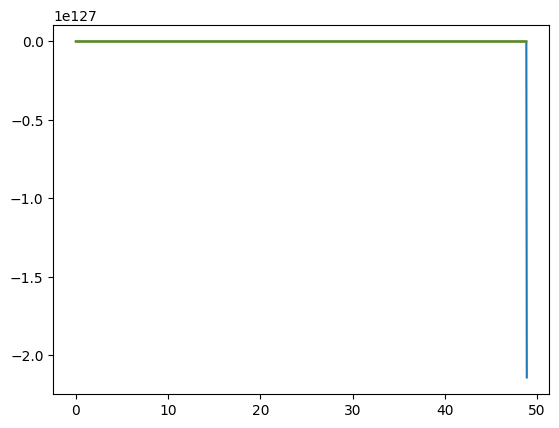

In [54]:
tTest = results[1]['t']
aTest = results[1]['y'][0]
mTest = results[1]['y'][1]
sTest = 1 - aTest - mTest 
plt.plot(tTest, aTest, label='a')
plt.plot(tTest, mTest, label='m')
plt.plot(tTest, sTest, label='s')
plt.show()

En este caso, diverge. Probaremos aislar el caso para poder facilmente cambiar los parametros.

C:\Users\Seba RC\AppData\Local\Temp\ipykernel_21420\844598422.py:7: RuntimeWarning: invalid value encountered in scalar power
  dmdt = k1 * (m**2) * a - k2 * (m**alpha) * s


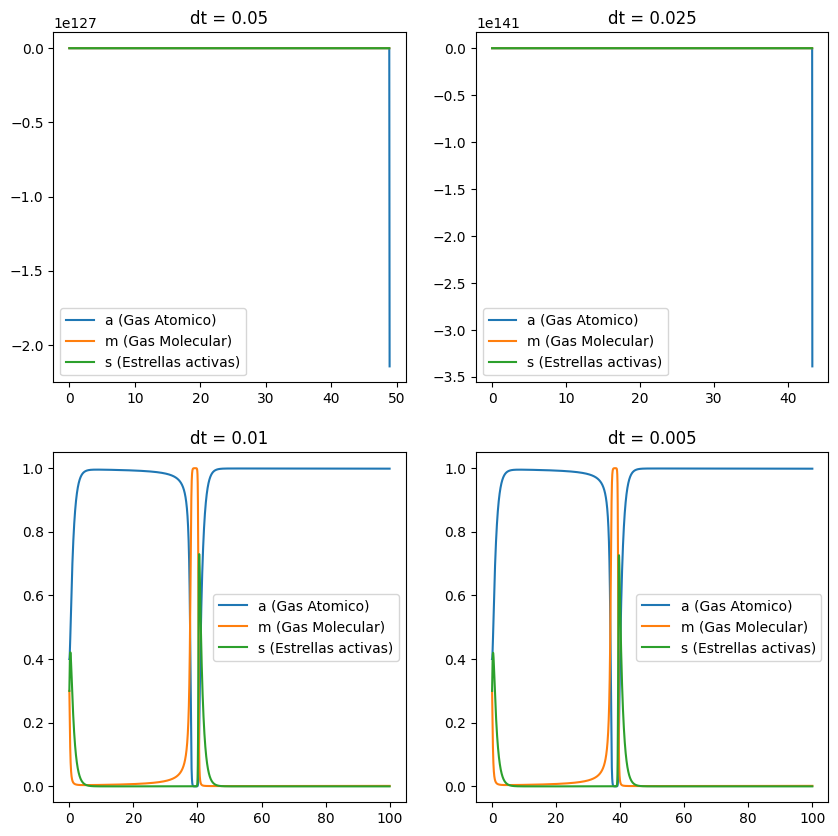

In [55]:
testParams = {"a0": params["a0"][1], "m0": params["m0"][1], "k1": params["k1"][1], "k2": params["k2"][1], "alpha": params["alpha"][1]}

y0 = [testParams["a0"], testParams["m0"]]
args = (testParams["k1"], testParams["k2"], testParams["alpha"]) 
# Probemos lentamente bajar el dt. Intentemos con diferentes valores de dt.
dtCases = [0.05, 0.025, 0.01, 0.005]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i in range(len(dtCases)):
    res = solveEuler(objFunc, 0, T, y0, dtCases[i], args=args)
    aTest = res['y'][0]
    mTest = res['y'][1]
    sTest = 1 - aTest - mTest

    axes[i].plot(res['t'], aTest, label='a (Gas Atomico)')
    axes[i].plot(res['t'], mTest, label='m (Gas Molecular)')
    axes[i].plot(res['t'], sTest, label='s (Estrellas activas)')
    axes[i].set_title(f"dt = {dtCases[i]}")
    axes[i].legend()

plt.savefig('ComparacionDTCaso2')
plt.show()



Bueno, al menos tenemos que los valores estan dentro del rango para estos valores iniciales con dt <= 0.01. <br>
Pero ahora, debemos ver los demas casos:

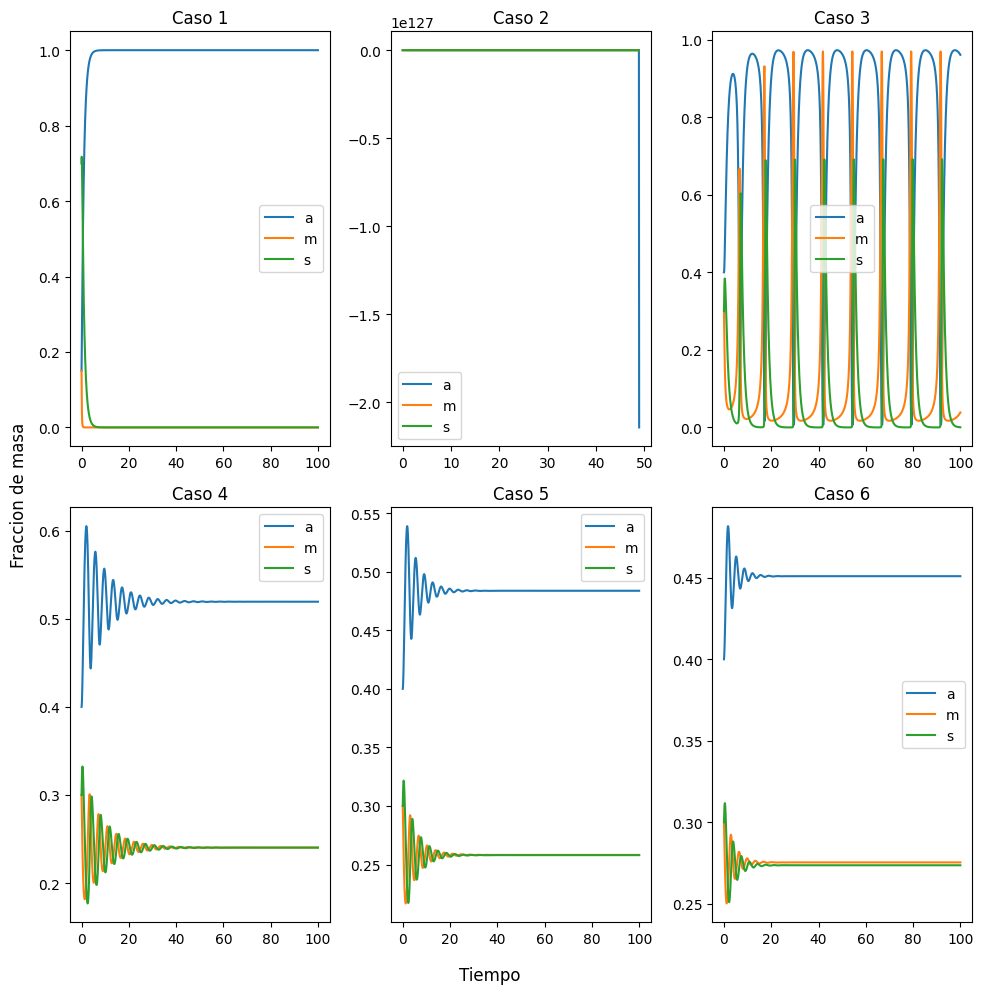

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes = axes.flatten()

for i, res in enumerate(results):
    a = res['y'][0]
    m = res['y'][1]
    s = 1 - a - m

    axes[i].plot(res['t'], a, label='a')
    axes[i].plot(res['t'], m, label='m')
    axes[i].plot(res['t'], s, label='s')
    axes[i].set_title(f"Caso {i+1}")
    axes[i].legend()

# Source - https://stackoverflow.com/a/65135433
# Posted by Oren, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-28, License - CC BY-SA 4.0
# fuente para fig.supxlabel (...) etc ^ plot loop fue mio

fig.supxlabel('Tiempo')
fig.supylabel('Fraccion de masa')

plt.tight_layout()
plt.savefig('ComparacionCasos')
plt.show()


2. Grafique en un plano (a(t) , m(t)) las trayectorias en función del tiempo (este plano es llamado plano de fases). Comente qué tipo de comportamiento observa en cada caso? e investigue y describa qué significa la evolución hacia un estado estacionario y la evolución hacia un ciclo límite.

Estos son los graficos que relacionan las trayectorias en funcion del tiempo:

C:\Users\Seba RC\AppData\Local\Temp\ipykernel_21420\992726031.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


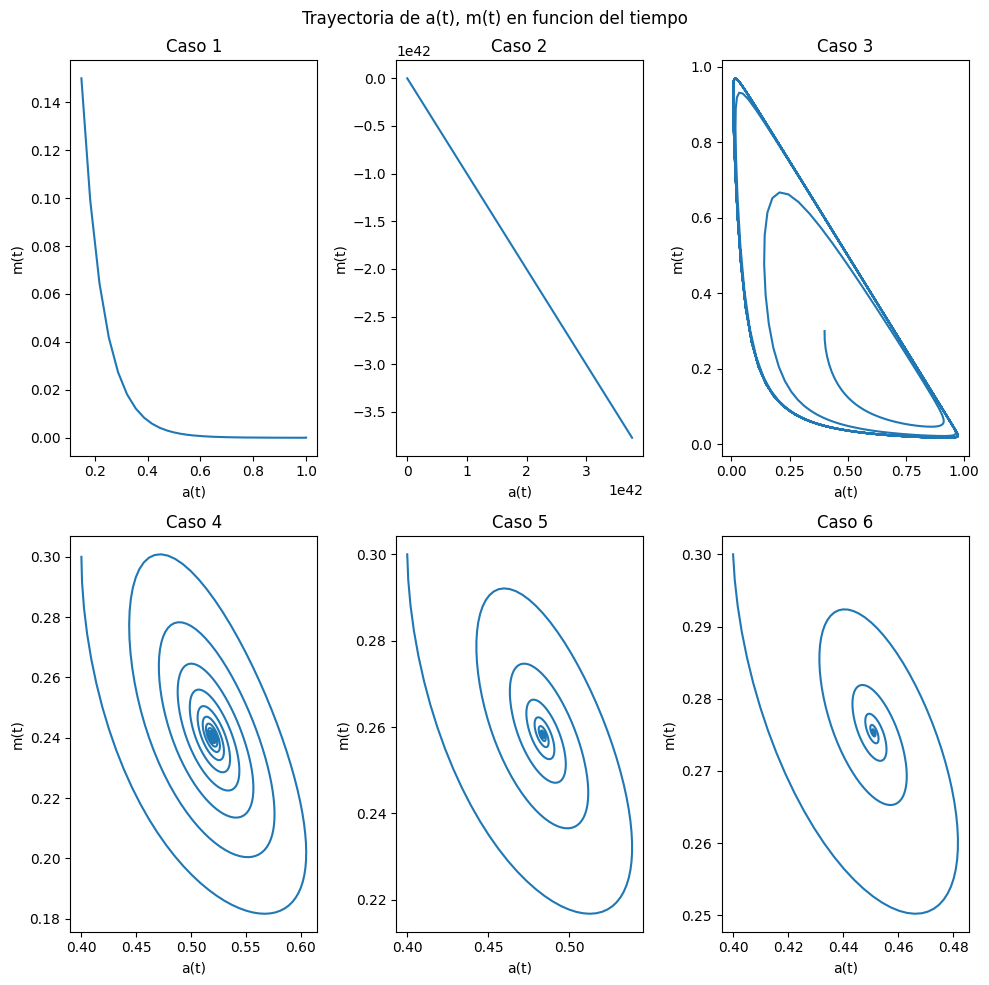

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes = axes.flatten()

for i, res in enumerate(results):
    a = res['y'][0]
    m = res['y'][1]


    axes[i].plot(a, m)
    axes[i].set_title(f"Caso {i+1}")
    axes[i].set_xlabel('a(t)')
    axes[i].set_ylabel('m(t)')

fig.suptitle("Trayectoria de a(t), m(t) en funcion del tiempo")
fig.tight_layout()
fig.savefig('TrayectoriaPorCaso')
fig.show()

Pero estos no nos dan suficiente informacion sobre COMO van cambiando las derivadas de las funciones en el tiempo. <br>

0 {'a0': 0.15, 'm0': 0.15, 'k1': 10, 'k2': 10, 'alpha': 1.0}
1 {'a0': 0.4, 'm0': 0.3, 'k1': 8, 'k2': 15, 'alpha': 1.2}
2 {'a0': 0.4, 'm0': 0.3, 'k1': 8, 'k2': 15, 'alpha': 1.5}
3 {'a0': 0.4, 'm0': 0.3, 'k1': 8, 'k2': 15, 'alpha': 1.9}
4 {'a0': 0.4, 'm0': 0.3, 'k1': 8, 'k2': 15, 'alpha': 2.0}
5 {'a0': 0.4, 'm0': 0.3, 'k1': 8, 'k2': 15, 'alpha': 2.1}


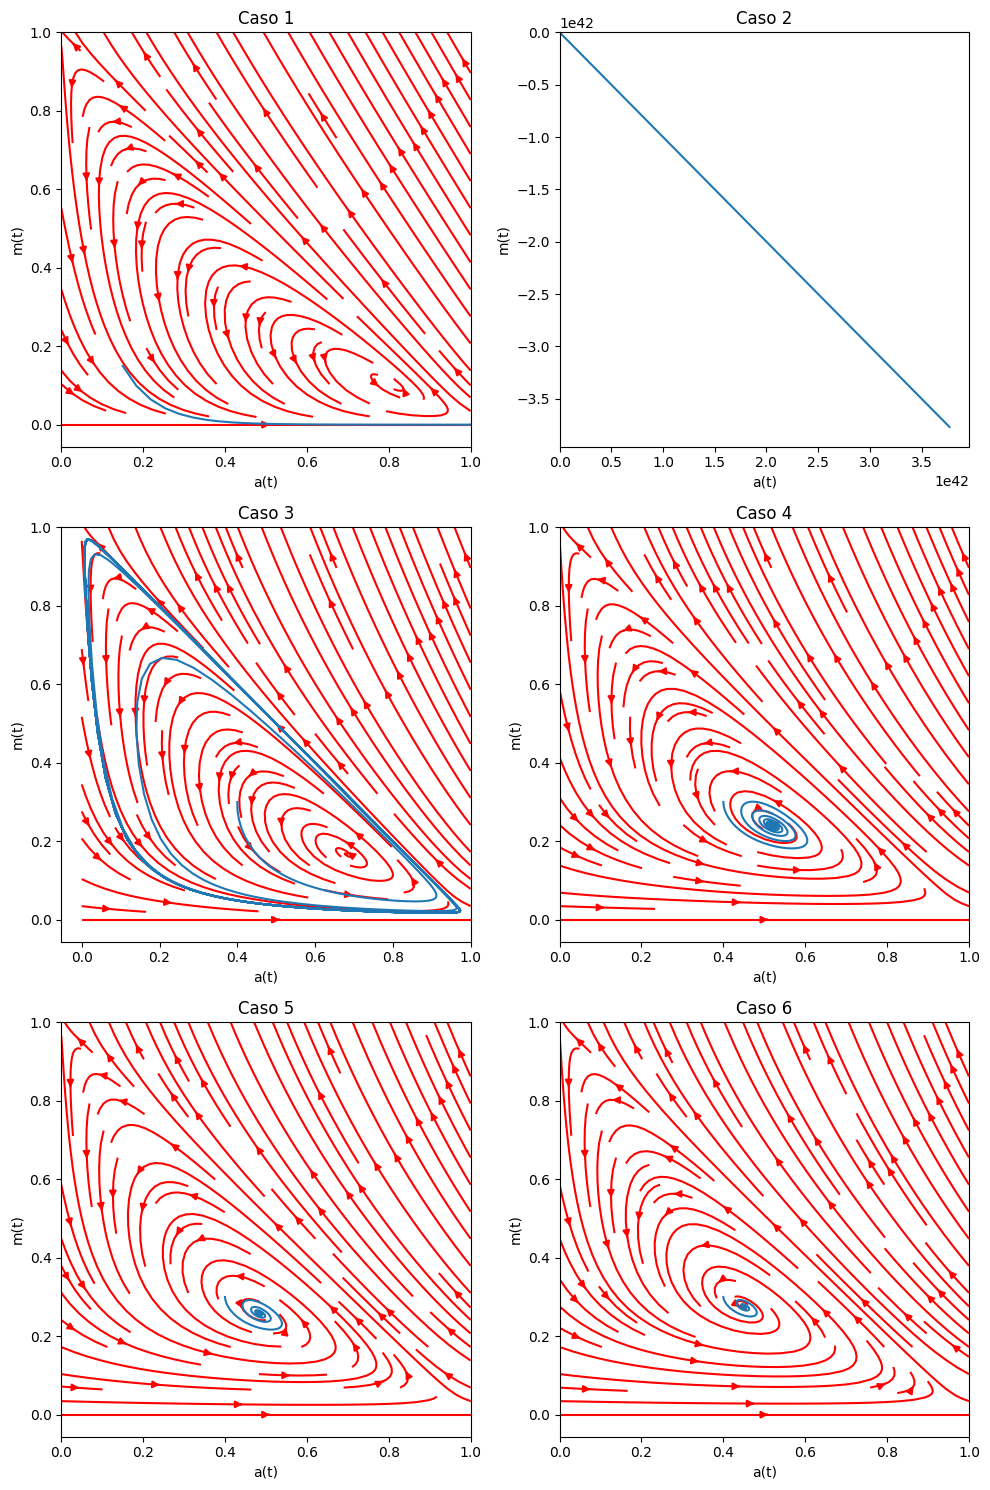

In [58]:

fig2, axis = plt.subplots(3, 2, figsize=(10, 15))
axisFlatten = axis.flatten()

for idx, case in enumerate(cases):
    ax = axisFlatten[idx]
    print(idx, case)
    k1, k2, alpha, t = case["k1"], case["k2"], case["alpha"], 0

    a_range = np.linspace(0, 1, 20)
    m_range = np.linspace(0, 1, 20)
    A, M = np.meshgrid(a_range, m_range)

    U = np.zeros(A.shape)
    V = np.zeros(M.shape)

    NI, NJ = A.shape 
    for i in range(NI):
        for j in range(NJ):
            current_y = [A[i, j], M[i, j]]

            derivs = objFunc(t, current_y, k1, k2, alpha)
            
            U[i, j] = derivs[0] # dadt
            V[i, j] = derivs[1] # dmdt

    # Evolucion de la derivada
    ax.streamplot(A, M, U, V, color=f'red')

    # Trayectoria c/r al tiempo
    res = results[idx]
    a = res['y'][0]
    m = res['y'][1]
    ax.plot(a, m)
    
    ax.set_title(f"Caso {idx+1}")
    ax.set_xlabel('a(t)')
    ax.set_ylabel('m(t)')


plt.tight_layout()
plt.savefig('phaseDiagramPorCaso')
plt.show()



Podemos ver que en los casos 4, 5 y 6 el sistema llega a un claro punto de equilibrio donde a pesar del paso del tiempo, los valores finales de m, a y s no cambian significativamente. 
En los casos 1 y 3 no se llega a un equilibrio claro, y en el caso 2 el sistema diverge si dt > 0.01.
El mapa de fases muestra la evolucion de las derivadas con respecto al tiempo de las variables a y m, y las flechas que representan este cambio cada vez se van volviendo mas pequeñas hasta llegar al punto de equilibrio en los casos 4, 5 y 6.

La evolución hacia un estado estacionario se refiere al proceso por el cual un sistema dinámico llega a un estado estable, donde sus variables principales permanecen "estacionarias" o consistentes a lo largo del tiempo.

Mientras tanto, la evolución hacia un ciclo límite se refiere a cuando el sistema no llega a un estado estable, sino que entre a un "bucle" luego de pasar un tiempo equilibrandose, llegando a presentar un comportamiento periodico donde el sistema oscila continuamente. Esto se puede observar en el caso 3 con cualquier dt observado, o en el caso 2 con un dt < 0.01.

3. Los siguientes ejercicios serán con los datos del segundo caso de la tabla pero
haciendo variar $1.3 \le \alpha \le 1.9$. Suponiendo que la evolución del sistema tiende a un cierto equilibrio periódico. Con qué frecuencia se reproducen las estrellas? Piense y programe algún algoritmo para estimar el periodo límite. Grafique este periodo límite en función de $\alpha$. Es
una función creciente o decreciente?

Primero, hagamos casos para alpha [1.3, 1.35, 1.45, 1.5, 1.55, 1.6, 1.65, 1.7, 1.75, 1.8, 1.85, 1.9], y visualizemos los datos.

C:\Users\Seba RC\AppData\Local\Temp\ipykernel_21420\844598422.py:7: RuntimeWarning: invalid value encountered in scalar power
  dmdt = k1 * (m**2) * a - k2 * (m**alpha) * s


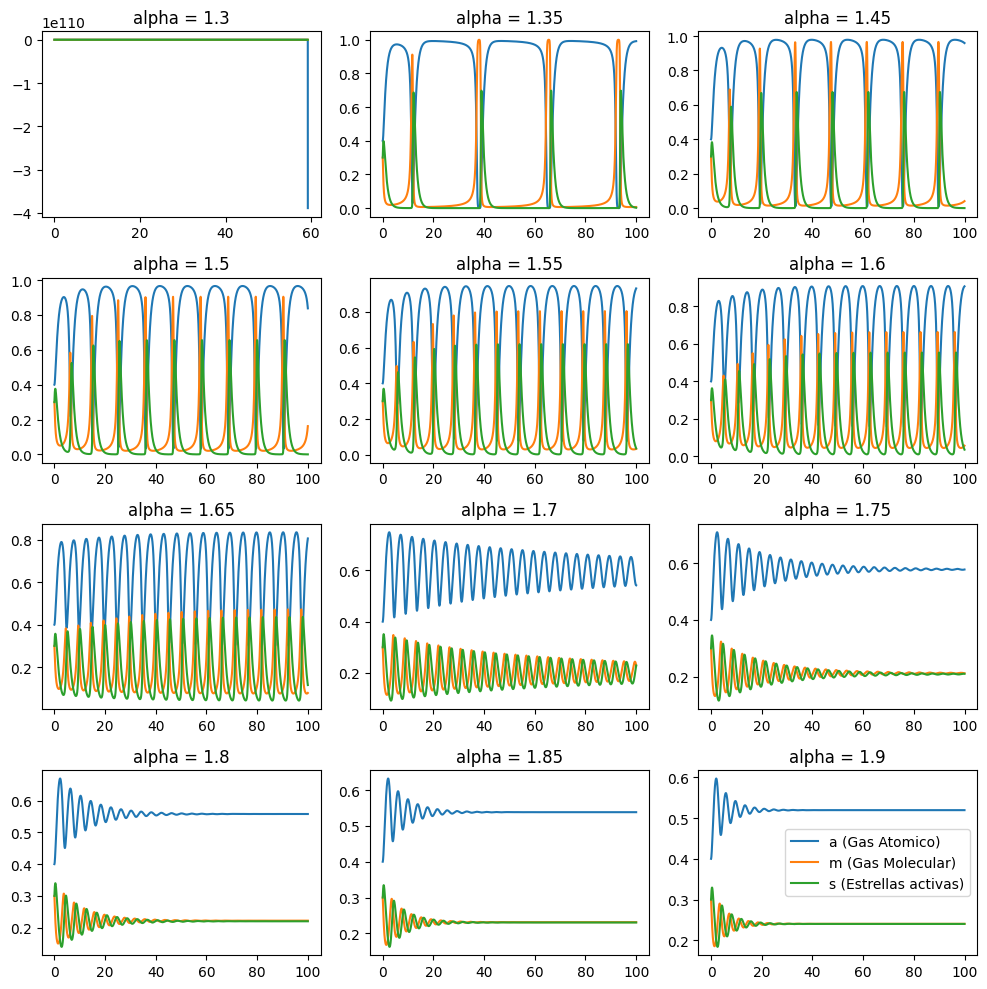

In [59]:

testParams = {"a0": params["a0"][1], "m0": params["m0"][1], "k1": params["k1"][1], "k2": params["k2"][1], "alpha": params["alpha"][1]}
alphacases = [1.3, 1.35, 1.45, 1.5, 1.55, 1.6, 1.65, 1.7, 1.75, 1.8, 1.85, 1.9] # casos de alpha a usar 
y0 = [testParams["a0"], testParams["m0"]]
args = (testParams["k1"], testParams["k2"], testParams["alpha"]) 



fig, axes = plt.subplots(4, 3, figsize=(10, 10))
axes = axes.flatten()
dt = 0.01

for i in range(len(alphacases)): # itera sobre los casos de alpha
    res = solveEuler(objFunc, 0, T, y0, dt, args=(testParams["k1"], testParams["k2"], alphacases[i]))
    aTest = res['y'][0]
    mTest = res['y'][1]
    sTest = 1 - aTest - mTest

    axes[i].plot(res['t'], aTest, label='a (Gas Atomico)')
    axes[i].plot(res['t'], mTest, label='m (Gas Molecular)')
    axes[i].plot(res['t'], sTest, label='s (Estrellas activas)')
    axes[i].set_title(f"alpha = {alphacases[i]}")
    
plt.legend()
plt.tight_layout()
plt.savefig('variacionAlphaEuler')
plt.show()



Para estimar el periodo limite, podemos calcular la distancia entre picos de la funcion:

C:\Users\Seba RC\AppData\Local\Temp\ipykernel_21420\844598422.py:7: RuntimeWarning: invalid value encountered in scalar power
  dmdt = k1 * (m**2) * a - k2 * (m**alpha) * s
c:\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[1.3, 1.325, 1.35, 1.375, 1.4, 1.425, 1.45, 1.475, 1.5, 1.525, 1.55, 1.575, 1.6, 1.625, 1.65, 1.6749999999999998, 1.7, 1.725, 1.75, 1.775, 1.7999999999999998, 1.825, 1.8499999999999999, 1.875, 1.9] [0.04913043478260874, nan, 27.5, 22.71, 19.120000000000005, 16.33, 14.135000000000002, 12.356666666666667, 10.88, 9.63, 8.546000000000001, 7.596000000000001, 6.743333333333333, 5.9625, 5.244444444444444, 4.6290000000000004, 4.291, 4.175454545454546, 4.105833333333334, 4.044545454545454, 3.9872727272727264, 3.934166666666666, 3.8825000000000003, 3.8341666666666665, 3.7875]


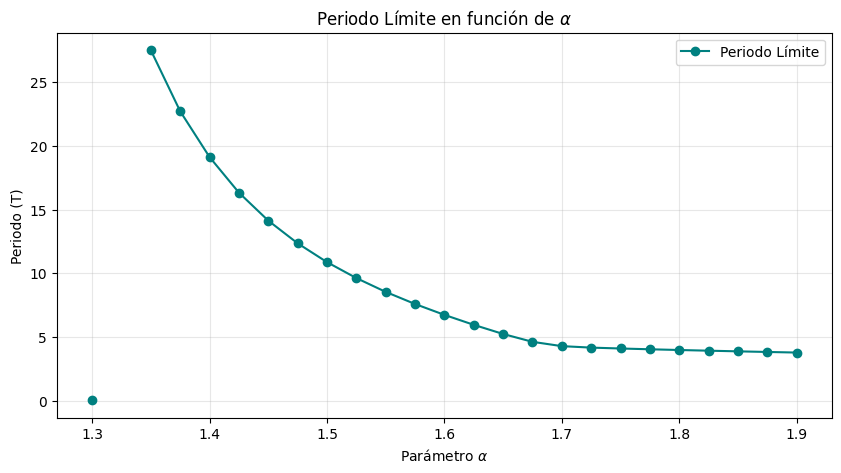

In [60]:
from time import time

def estimar_periodo_limite(t, s):
    # Evitamos el periodo transitorio inicial
    mitad = len(t) // 2
    t_est = t[mitad:]
    s_est = s[mitad:]
    
    picos_t = []
    # Detección de picos
    for i in range(1, len(s_est) - 1):
        if s_est[i] > s_est[i-1] and s_est[i] > s_est[i+1]:
            picos_t.append(t_est[i])
    
    # Diferencia promedio entre picos consecutivos
    periodos = [picos_t[i+1] - picos_t[i] for i in range(len(picos_t) - 1)]
    return np.mean(periodos)


testParams = {"a0": params["a0"][1], "m0": params["m0"][1], "k1": params["k1"][1], "k2": params["k2"][1], "alpha": params["alpha"][1]}
t0, T_final, dt = 0, 100, 0.01 
alphas = np.linspace(1.3, 1.9, 25)

resultados_periodo = []
alphas_validos = []

eulerTime = time()
for a in alphas:
    res = solveEuler(objFunc, t0, T_final, y0, dt, args=(testParams["k1"], testParams["k2"], a))
    t = res['t']
    s = 1 - res['y'][0] - res['y'][1]
    
    periodo = estimar_periodo_limite(t, s)
    
    resultados_periodo.append(periodo)
    alphas_validos.append(a)
eulerTime2 = time()

print(alphas_validos, resultados_periodo)
plt.figure(figsize=(10, 5))
plt.plot(alphas_validos, resultados_periodo, 'o-', color='teal', label='Periodo Límite')
plt.title(r'Periodo Límite en función de $\alpha$')
plt.xlabel(r'Parámetro $\alpha$')
plt.ylabel('Periodo (T)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('periodoLimiteEuler')
plt.show()
eulerTimeTaken = eulerTime2 - eulerTime



Podemos ver que es una funcion decreciente.

4. Resuelva el mismo problema (3), pero esta vez usando Runge-Kutta de orden 4 (debe programar el método primero usted mismo). Se reproducen con la misma frecuencia las estrellas? Compare con lo que obtuvo en la parte (c) para un mismo paso de tiempo.

In [61]:
def solveRK4(fun, t0, T, y0, dt, args=()):
    tVal = np.arange(t0, T + dt, dt)
    yVal = np.zeros((len(tVal), len(y0)))
    yVal[0] = y0
    
    for i in range(1, len(tVal)):
        t = tVal[i-1]
        y = yVal[i-1]
        h = dt 
        
        # Calculo de RK4
        # usamos *args en vez de args para pasar a la funcion una tupla con los argumentos
        k1 = np.array(fun(t, y, *args))
        k2 = np.array(fun(t + h/2, y + h*k1/2, *args))
        k3 = np.array(fun(t + h/2, y + h*k2/2, *args))
        k4 = np.array(fun(t + h, y + h*k3, *args))
        
        # Combinación de RK4
        yVal[i] = y + (h*(k1 + 2*k2 + 2*k3 + k4))/6

    return {
        't': tVal, 
        'y': yVal.T  # Index 0 = a, Index 1 = m
    }
testParams = {"a0": params["a0"][1], "m0": params["m0"][1], "k1": params["k1"][1], "k2": params["k2"][1], "alpha": params["alpha"][1]}
y0 = [testParams["a0"], testParams["m0"]]
args = (testParams["k1"], testParams["k2"], testParams["alpha"]) 
t0, T_final, dt = 0, 100, 0.01 

solveRK4(objFunc, t0, T_final, y0, dt, args)

{'t': array([0.000e+00, 1.000e-02, 2.000e-02, ..., 9.998e+01, 9.999e+01,
        1.000e+02]),
 'y': array([[0.4       , 0.40023098, 0.40068033, ..., 0.99827592, 0.99827569,
         0.99827545],
        [0.3       , 0.29222914, 0.28439651, ..., 0.00172408, 0.00172431,
         0.00172455]])}

Ahi tenemos nuestra funcion RK4. Ahora, iteremos sobre algunos casos de alpha y comparemos cada uno:

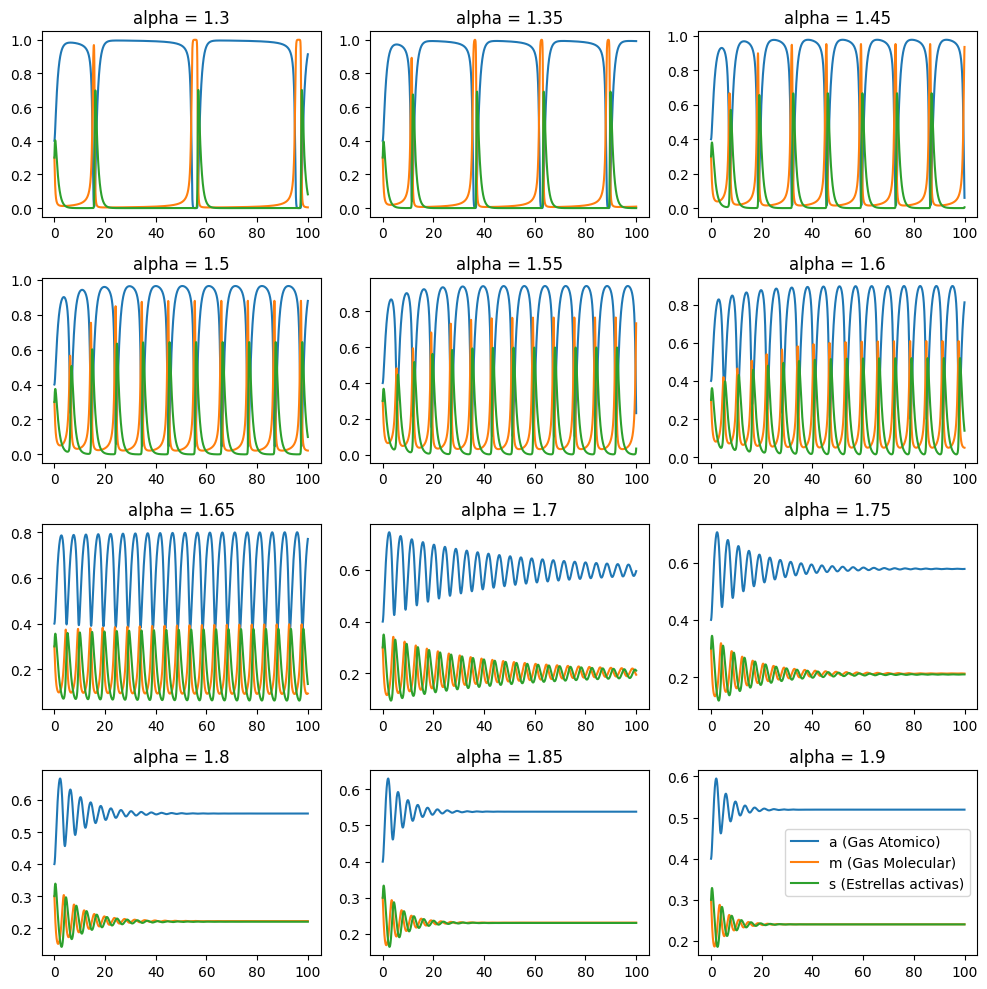

In [62]:

fig, axes = plt.subplots(4, 3, figsize=(10, 10))
axes = axes.flatten()
dt = 0.01


for i in range(len(alphacases)): # itera sobre los casos de alpha
    res = solveRK4(objFunc, 0, T_final, y0, dt, args=(testParams["k1"], testParams["k2"], alphacases[i]))
    aTest = res['y'][0]
    mTest = res['y'][1]
    sTest = 1 - aTest - mTest

    axes[i].plot(res['t'], aTest, label='a (Gas Atomico)')
    axes[i].plot(res['t'], mTest, label='m (Gas Molecular)')
    axes[i].plot(res['t'], sTest, label='s (Estrellas activas)')
    axes[i].set_title(f"alpha = {alphacases[i]}")

plt.legend()
plt.tight_layout()
plt.savefig('variacionAlphaRK')
plt.show()


Y la progresion de las frecuencias se ve asi:

[1.3, 1.325, 1.35, 1.375, 1.4, 1.425, 1.45, 1.475, 1.5, 1.525, 1.55, 1.575, 1.6, 1.625, 1.65, 1.6749999999999998, 1.7, 1.725, 1.75, 1.775, 1.7999999999999998, 1.825, 1.8499999999999999, 1.875, 1.9] [0.33758865248226944, nan, 26.339999999999996, 21.835, 18.419999999999998, 15.765, 13.650000000000002, 11.92, 10.472499999999998, 9.2375, 8.163999999999998, 7.2200000000000015, 6.374285714285714, 5.606250000000001, 4.9188888888888895, 4.4363636363636365, 4.251818181818181, 4.171818181818182, 4.1066666666666665, 4.047272727272728, 3.9918181818181817, 3.9374999999999996, 3.8866666666666667, 3.8391666666666673, 3.794166666666667]


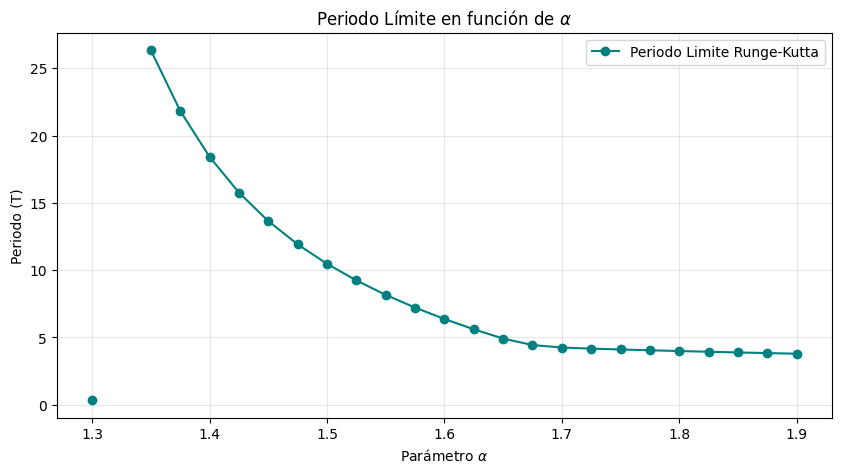

In [63]:
alphas = np.linspace(1.3, 1.9, 25)

resultados_periodork = []
alphas_validosrk = []

RK4Time1 = time()
for a in alphas:
    res = solveRK4(objFunc, t0, T_final, y0, dt, args=(testParams["k1"], testParams["k2"], a))
    t = res['t']
    s = 1 - res['y'][0] - res['y'][1]
    
    periodo = estimar_periodo_limite(t, s)
    
    resultados_periodork.append(periodo)
    alphas_validosrk.append(a)

RK4Time2 = time()
RK4TimeTaken = RK4Time2 - RK4Time1
print(alphas_validosrk, resultados_periodork)
    
plt.figure(figsize=(10, 5))
plt.plot(alphas_validosrk, resultados_periodork, 'o-', color='teal', label='Periodo Limite Runge-Kutta')
plt.title(r'Periodo Límite en función de $\alpha$')
plt.xlabel(r'Parámetro $\alpha$')
plt.ylabel('Periodo (T)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('periodoLimiteRK')
plt.show()



Podemos ver que pudo estimar un periodo para el parametro alpha = 1.3, y tambien tenemos resultados de alphas menores! 
Podemos superponer los graficos para ver la diferencia exacta:

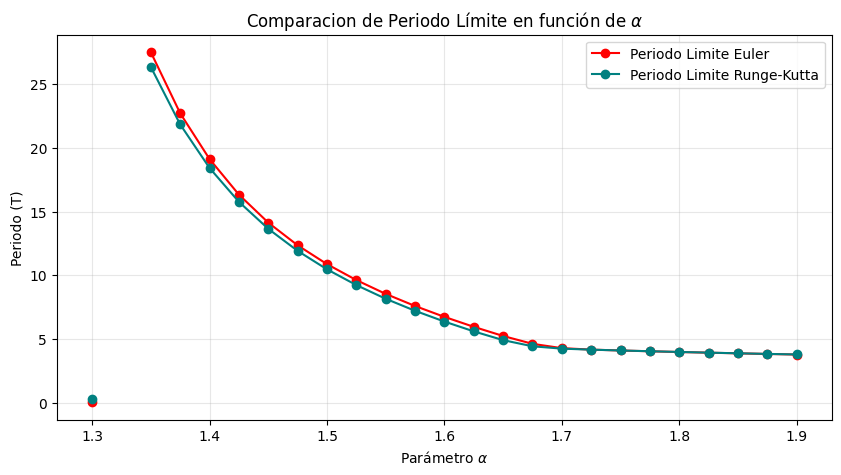

In [64]:
plt.figure(figsize=(10, 5))
plt.plot(alphas_validos, resultados_periodo, 'o-', color='red', label='Periodo Limite Euler')
plt.plot(alphas_validosrk, resultados_periodork, 'o-', color='teal', label='Periodo Limite Runge-Kutta')
plt.title(r'Comparacion de Periodo Límite en función de $\alpha$')
plt.xlabel(r'Parámetro $\alpha$')
plt.ylabel('Periodo (T)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Podemos tambien ver que al avanzar el parametro alpha, existe una menor diferencia entre ambos metodos.

Probemos hacer un DataFrame para ver como avanza esta diferencia.

In [65]:
import pandas as pd
display(abs(resultados_periodo[2]-resultados_periodork[2]))
diff = [(abs(resultados_periodo[i]-resultados_periodork[i])) for i in range(len(alphas_validos))]
df = pd.DataFrame(data={
    'Alpha':alphas_validos,
    'Periodo Euler':resultados_periodo,
    'Periodo RK4': resultados_periodork,
    'Diferencia': diff
})
dfComparison = pd.DataFrame(data={
    'TiempoEjecucion': {'Euler': eulerTimeTaken, 'RK4': RK4TimeTaken}
})
display(df)
display(dfComparison)

1.1600000000000037

,Alpha,Periodo Euler,Periodo RK4,Diferencia
0,1.300,0.049130,0.337589,0.288458
1,1.325,NaN,NaN,NaN
2,1.350,27.500000,26.340000,1.160000
3,1.375,22.710000,21.835000,0.875000
4,1.400,19.120000,18.420000,0.700000
5,1.425,16.330000,15.765000,0.565000
6,1.450,14.135000,13.650000,0.485000
7,1.475,12.356667,11.920000,0.436667
8,1.500,10.880000,10.472500,0.407500
9,1.525,9.630000,9.237500,0.392500


,TiempoEjecucion
Euler,3.145497
RK4,16.506761


Resuelva el mismo problema (c) pero esta vez usando la librería vista en clases, utilice todos los distintos metodos que ella contiene, que sean posible de usar, y compare con los resultados obtenidos en (3) y (4) graficando los tres resultados en un solo gráfico y etiquetando las curvas.

La libreria usada sera solve_ivp. Para esta, debemos usar los siguientes metodos:
- RK45
- RK23
- DOP853
- Radau
- BDF
- LSODA

In [66]:
from scipy.integrate import solve_ivp

# redefinir params comunes. Recordar que estamos usando el caso 2
testParams = {"a0": params["a0"][1], "m0": params["m0"][1], "k1": params["k1"][1], "k2": params["k2"][1], "alpha": a}
y0 = [testParams["a0"], testParams["m0"]]
args = (testParams["k1"], testParams["k2"], testParams["alpha"]) 
t0, T_final, dt = 0, 100, 0.01 
t_span = (0, 100)
# para un dt de 0.01..
t_eval = np.linspace(0, 100, 10000)

Lo que haremos es graficar las 3 curvas de trayectoria para euler, rk y todas las curvas de solve_ivp.

In [67]:

# recordar que para solve_ivp:
# t = method.t
# a = method.y[0]
# m = method.y[1]
# s = 1 - a - m

alphas = np.linspace(1.3, 1.9, 25)
# Creacion de figuras

# RK45
resultados_periodork45 = []
alphas_validosrk45 = []

RK45Time1 = time()
for a in alphas:
    res = solve_ivp(fun=objFunc,t_span=t_span,y0=y0, method='RK45',args=(testParams["k1"], testParams["k2"], a),t_eval=t_eval)
    t = res.t
    s = 1 - res.y[0] - res.y[1]
    
    periodo = estimar_periodo_limite(t, s)
    
    resultados_periodork45.append(periodo)
    alphas_validosrk45.append(a)
RK45Time2 = time()
RK45TimeTaken = RK45Time2 - RK45Time1

# RK23
resultados_periodork23 = []
alphas_validosrk23 = []
RK23Time1 = time()

for a in alphas:
    res = solve_ivp(fun=objFunc,t_span=t_span,y0=y0, method='RK23',args=(testParams["k1"], testParams["k2"], a),t_eval=t_eval)
    t = res.t
    s = 1 - res.y[0] - res.y[1]
    
    periodo = estimar_periodo_limite(t, s)
    
    resultados_periodork23.append(periodo)
    alphas_validosrk23.append(a)

RK23Time2 = time()
RK23TimeTaken = RK23Time2 - RK23Time1

# DOP853
resultados_periododop853 = []
alphas_validosdop853 = []
DOP853Time1 = time()

for a in alphas:
    res = solve_ivp(fun=objFunc,t_span=t_span,y0=y0, method='DOP853',args=(testParams["k1"], testParams["k2"], a),t_eval=t_eval)
    t = res.t
    s = 1 - res.y[0] - res.y[1]
    
    periodo = estimar_periodo_limite(t, s)
    
    resultados_periododop853.append(periodo)
    alphas_validosdop853.append(a)

DOP853Time2 = time()
DOP853TimeTaken = DOP853Time2 - DOP853Time1

# Radau
resultados_periodoRadau = []
alphas_validosRadau = []

RadauTime1 = time()

for a in alphas:
    res = solve_ivp(fun=objFunc,t_span=t_span,y0=y0, method='Radau',args=(testParams["k1"], testParams["k2"], a),t_eval=t_eval)
    t = res.t
    s = 1 - res.y[0] - res.y[1]
    
    periodo = estimar_periodo_limite(t, s)
    
    resultados_periodoRadau.append(periodo)
    alphas_validosRadau.append(a)

RadauTime2 = time()
RadauTimeTaken = RadauTime2 - RadauTime1

# BDF
resultados_periodoBDF = []
alphas_validosBDF = []

BDFTime1 = time()

for a in alphas:
    res = solve_ivp(fun=objFunc,t_span=t_span,y0=y0, method='BDF',args=(testParams["k1"], testParams["k2"], a),t_eval=t_eval)
    t = res.t
    s = 1 - res.y[0] - res.y[1]
    
    periodo = estimar_periodo_limite(t, s)
    
    resultados_periodoBDF.append(periodo)
    alphas_validosBDF.append(a)

BDFTime2 = time()
BDFTimeTaken = BDFTime2 - BDFTime1

# LSODA
resultados_periodolsoda = []
alphas_validoslsoda = []

lsodatime1 = time()
for a in alphas:
    res = solve_ivp(fun=objFunc,t_span=t_span,y0=y0, method='LSODA',args=(testParams["k1"], testParams["k2"], a),t_eval=t_eval)
    t = res.t
    s = 1 - res.y[0] - res.y[1]
    
    periodo = estimar_periodo_limite(t, s)
    
    resultados_periodolsoda.append(periodo)
    alphas_validoslsoda.append(a)

lsodatime2 = time()
lsodaTimeTaken = lsodatime2 - lsodatime1

C:\Users\Seba RC\AppData\Local\Temp\ipykernel_21420\844598422.py:7: RuntimeWarning: invalid value encountered in scalar power
  dmdt = k1 * (m**2) * a - k2 * (m**alpha) * s
c:\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Seba RC\AppData\Local\Temp\ipykernel_21420\844598422.py:7: RuntimeWarning: overflow encountered in scalar multiply
  dmdt = k1 * (m**2) * a - k2 * (m**alpha) * s
C:\Users\Seba RC\AppData\Local\Temp\ipykernel_21420\844598422.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  s = 1 - a - m
c:\Python311\Lib\site-packages\scipy\integrate\_ode.py:1348: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  warnings.warn('{:s}: {:s}'.format(self.__class__.__name__,


C:\Users\Seba RC\AppData\Local\Temp\ipykernel_21420\3377807108.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


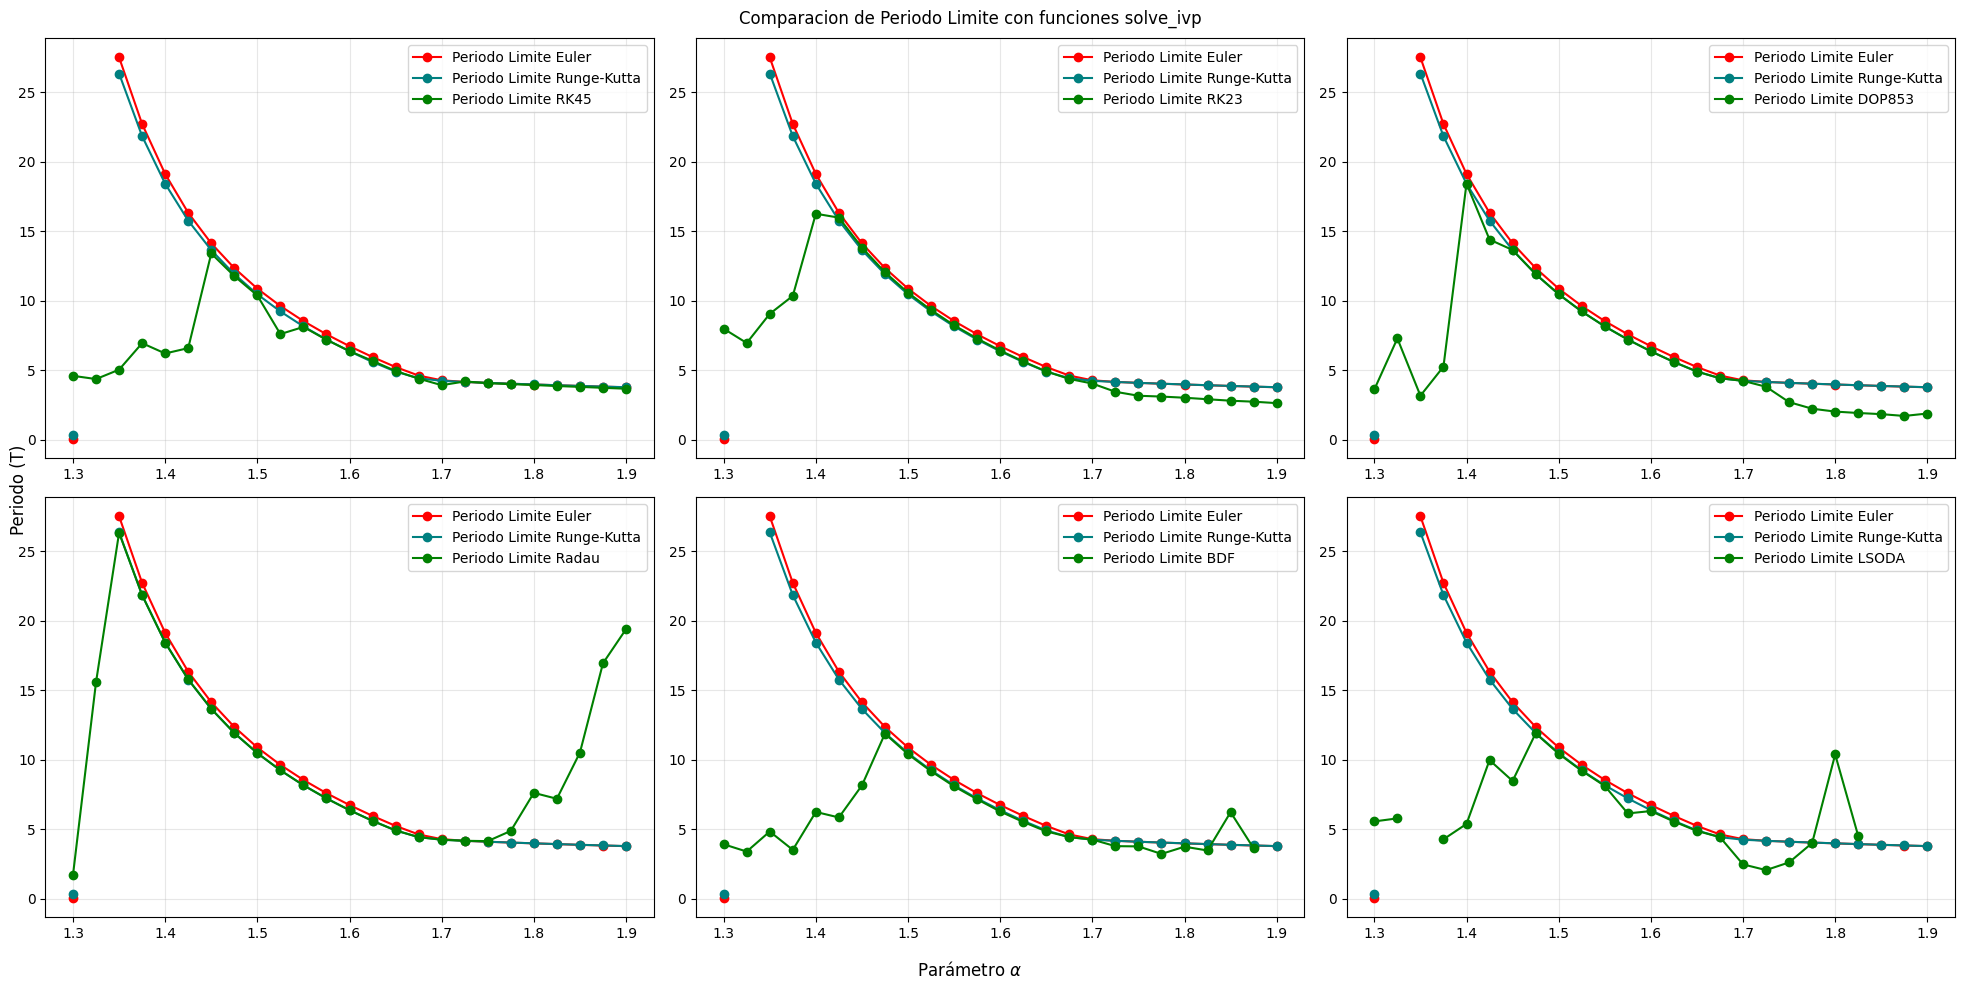

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(20,10))
axes = axes.flatten()

# PLOT RK45
axes[0].plot(alphas_validos, resultados_periodo, 'o-', color='red', label='Periodo Limite Euler')
axes[0].plot(alphas_validosrk, resultados_periodork, 'o-', color='teal', label='Periodo Limite Runge-Kutta')
axes[0].plot(alphas_validosrk45, resultados_periodork45, 'o-', color='green', label='Periodo Limite RK45')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# PLOT RK23
axes[1].plot(alphas_validos, resultados_periodo, 'o-', color='red', label='Periodo Limite Euler')
axes[1].plot(alphas_validosrk, resultados_periodork, 'o-', color='teal', label='Periodo Limite Runge-Kutta')
axes[1].plot(alphas_validosrk23, resultados_periodork23, 'o-', color='green', label='Periodo Limite RK23')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# PLOT DOP853
axes[2].plot(alphas_validos, resultados_periodo, 'o-', color='red', label='Periodo Limite Euler')
axes[2].plot(alphas_validosrk, resultados_periodork, 'o-', color='teal', label='Periodo Limite Runge-Kutta')
axes[2].plot(alphas_validosdop853, resultados_periododop853, 'o-', color='green', label='Periodo Limite DOP853')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

# PLOT RADAU
axes[3].plot(alphas_validos, resultados_periodo, 'o-', color='red', label='Periodo Limite Euler')
axes[3].plot(alphas_validosrk, resultados_periodork, 'o-', color='teal', label='Periodo Limite Runge-Kutta')
axes[3].plot(alphas_validosRadau, resultados_periodoRadau, 'o-', color='green', label='Periodo Limite Radau')
axes[3].grid(True, alpha=0.3)
axes[3].legend()

# PLOT BDF
axes[4].plot(alphas_validos, resultados_periodo, 'o-', color='red', label='Periodo Limite Euler')
axes[4].plot(alphas_validosrk, resultados_periodork, 'o-', color='teal', label='Periodo Limite Runge-Kutta')
axes[4].plot(alphas_validosBDF, resultados_periodoBDF, 'o-', color='green', label='Periodo Limite BDF')
axes[4].grid(True, alpha=0.3)
axes[4].legend()

# PLOT LSODA
axes[5].plot(alphas_validos, resultados_periodo, 'o-', color='red', label='Periodo Limite Euler')
axes[5].plot(alphas_validosrk, resultados_periodork, 'o-', color='teal', label='Periodo Limite Runge-Kutta')
axes[5].plot(alphas_validoslsoda, resultados_periodolsoda, 'o-', color='green', label='Periodo Limite LSODA')
axes[5].grid(True, alpha=0.3)
axes[5].legend()

fig.suptitle('Comparacion de Periodo Limite con funciones solve_ivp')
fig.supxlabel(r'Parámetro $\alpha$')
fig.supylabel('Periodo (T)')
fig.tight_layout()
fig.savefig('ComparacionSolveIVP')
fig.show()

Podemos tambien hacer un dataframe con estos resultados:

In [69]:
df = pd.DataFrame(data={
    'Alpha':alphas_validos,
    'Periodo Euler':resultados_periodo,
    'Periodo RK4': resultados_periodork,
    'Periodo RK45': resultados_periodork45,
    'Periodo RK23': resultados_periodork23,
    'Periodo DOP853': resultados_periododop853,
    'Periodo Radau': resultados_periodoRadau,
    'Periodo BDF': resultados_periodoBDF,
    'Periodo LSODA': resultados_periodolsoda
})


Ahora, para calcular el error... deberemos llevar a cabo una simulacion de alta precision para obtener una referencia, ya que no hay solucion analitica. Usemos DOP853.

In [ ]:
periodosRef = []
refTime1 = time()
for a in alphas:
    res_ref = solve_ivp(fun=objFunc, t_span=t_span, y0=y0, method='DOP853', 
                        args=(testParams["k1"], testParams["k2"], a), 
                        t_eval=t_eval, rtol=1e-15, atol=1e-17)
    s_ref = 1 - res_ref.y[0] - res_ref.y[1]
    periodoRef = estimar_periodo_limite(res_ref.t, s_ref)
    periodosRef.append(periodoRef)
refTime2 = time()
refTimeTaken = refTime2 - refTime1
print(f'Tiempo para el calculo de referencia: {refTimeTaken}')

c:\Python311\Lib\site-packages\scipy\integrate\_ivp\common.py:47: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  warn("At least one element of `rtol` is too small. "


In [71]:
periodosRef

errorEuler = []
errorRK4 = []
errorRK45 = []
errorRK23 = []
errorDOP853 = []
errorRadau = []
errorBDF = []
errorLSODA = []

# si, estoy completamente de acuerdo con que hay un metodo mejor que este.
# en mi defensa, estoy con una fiebre de 38 grados, mi garganta está sinceramente molesta conmigo, y me di cuenta que no agregué errores a las 1 AM del domingo.
# agradezco su comprensión

for periodo in (resultados_periodo):
    errorRelativo = abs(periodo - periodosRef[i]) / periodosRef[i]
    errorEuler.append(errorRelativo)

for periodo in (resultados_periodork):
    errorRelativo = abs(periodo - periodosRef[i]) / periodosRef[i]
    errorRK4.append(errorRelativo)

for periodo in (resultados_periodork45):
    errorRelativo = abs(periodo - periodosRef[i]) / periodosRef[i]
    errorRK45.append(errorRelativo)

for periodo in (resultados_periodork23):
    errorRelativo = abs(periodo - periodosRef[i]) / periodosRef[i]
    errorRK23.append(errorRelativo)

for periodo in (resultados_periododop853):
    errorRelativo = abs(periodo - periodosRef[i]) / periodosRef[i]
    errorDOP853.append(errorRelativo)

for periodo in (resultados_periodoRadau):
    errorRelativo = abs(periodo - periodosRef[i]) / periodosRef[i]
    errorRadau.append(errorRelativo)

for periodo in (resultados_periodoBDF):
    errorRelativo = abs(periodo - periodosRef[i]) / periodosRef[i]
    errorBDF.append(errorRelativo)

for periodo in (resultados_periodolsoda):
    errorRelativo = abs(periodo - periodosRef[i]) / periodosRef[i]
    errorLSODA.append(errorRelativo)

np.nanmean(errorLSODA)

0.3625139358178938

In [72]:
finalComparison = pd.DataFrame(data={
                             'Error Promedio': {'Euler': np.nanmean(errorEuler), 'RK4': np.nanmean(errorRK4), 'RK45': np.nanmean(errorRK45), 'RK23': np.nanmean(errorRK23), 'DOP853': np.nanmean(errorDOP853), 'Radau': np.nanmean(errorRadau), 'BDF': np.nanmean(errorBDF), 'LSODA': np.nanmean(errorLSODA)},
                             'TiempoEjecucion': {'Euler': eulerTimeTaken, 'RK4': RK4TimeTaken, 'RK45': RK45TimeTaken, 'RK23': RK23TimeTaken, 'DOP853': DOP853TimeTaken, 'Radau': RadauTimeTaken, 'BDF': BDFTimeTaken, 'LSODA': lsodaTimeTaken}  
                               }
                               )
finalComparison


,Error Promedio,TiempoEjecucion
Euler,0.686772,3.145497
RK4,0.659030,16.506761
RK45,0.342440,0.863077
RK23,0.478065,2.846023
DOP853,0.528567,4.124674
Radau,0.715846,4.592516
BDF,0.349704,4.784677
LSODA,0.362514,1.753457
